# Практика: DBSCAN — плотностная кластеризация

## Что вы сделаете
В этом ноутбуке вы:

1. исследуете нелинейные 2D-датасеты и убедитесь в ограничениях K-Means;
2. построите **k-distance plot** и выберете оптимальный параметр `eps`;
3. применените **DBSCAN** и проанализируете результаты;
4. сравните DBSCAN с K-Means на нелинейных данных;
5. исследуете влияние гиперпараметров `eps` и `min_samples`;
6. применените DBSCAN к реальному датасету **Wine** и проанализируете шумовые точки;
7. сравните силуэт DBSCAN и K-Means, сделаете выводы.

## Важно
- Заполняйте все ячейки с пометкой `# YOUR CODE HERE`.
- Не удаляйте проверки: они подскажут, правильно ли вы идёте.
- Вопросы для размышления помогут вам глубже понять алгоритм.

## Датасеты
- **`make_moons`** и **`make_circles`** из `sklearn.datasets`: 2D-данные с нелинейными кластерами.
- **Wine** (`load_wine`): реальный многомерный датасет (13 признаков, 3 класса).

## Что сдавать
1. Заполненный ноутбук со всеми графиками.
2. Краткие выводы в конце каждого раздела.
3. Итоговый вывод: когда DBSCAN лучше K-Means и когда нет.

## Краткая теория

### Типы точек в DBSCAN

DBSCAN задаётся двумя параметрами: радиусом окрестности `eps` (ε) и минимальным числом точек `min_samples`.

- **Корневая точка** (core): в её ε-окрестности ≥ `min_samples` точек.
- **Граничная точка** (border): в её ε-окрестности < `min_samples`, но она достижима из корневой.
- **Шумовая точка** (noise): не является ни корневой, ни граничной → метка **-1**.

### Как работает алгоритм

1. Для каждой непосещённой точки найти её ε-окрестность.
2. Если точек ≥ `min_samples` — начать новый кластер.
3. Рекурсивно расширить кластер через цепочки плотно достижимых точек.
4. Оставшиеся точки → шум (метка -1).

### Как выбрать eps: k-distance plot

Для каждой точки вычисляют расстояние до её k-го ближайшего соседа (k = `min_samples`). Отсортированный по убыванию график этих расстояний называется **k-distance plot**. Резкий перегиб («локоть») указывает на оптимальное значение `eps`.

---
## Шаг 1. Импорты и настройки

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles, load_wine
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Импорты выполнены успешно!")

Импорты выполнены успешно!


---
## Шаг 2. Исследование нелинейных датасетов

Сгенерируем два датасета, с которыми K-Means заведомо не справится.

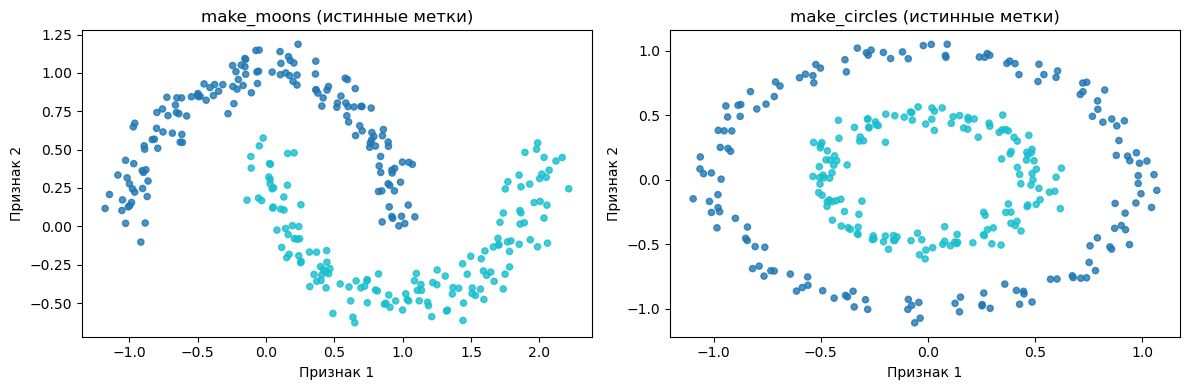

In [2]:
# Генерация датасетов
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05,
                                     factor=0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=y_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("make_moons (истинные метки)")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=y_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("make_circles (истинные метки)")
axes[1].set_xlabel("Признак 1")
axes[1].set_ylabel("Признак 2")

plt.tight_layout()
plt.show()

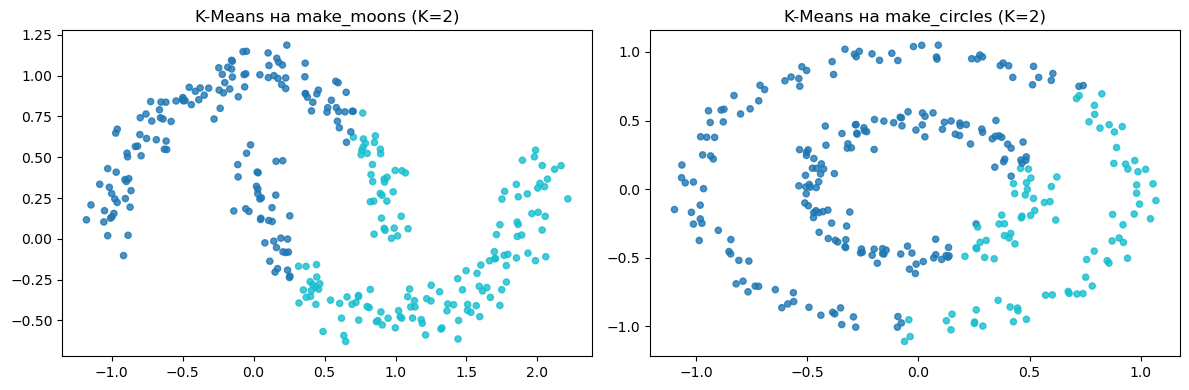

In [3]:
# Применим K-Means к этим датасетам
# YOUR CODE HERE
# 1. Создайте KMeans с n_clusters=2, random_state=RANDOM_STATE
# 2. Обучите на X_moons и X_circles
# 3. Получите метки кластеров

kmeans_moons = KMeans(random_state=RANDOM_STATE, n_clusters=2, init='k-means++').fit(X_moons) #посмотрел что получится если k_means++
#к слову визуально сравнив картинки видно что ничего не поменялось
labels_km_moons = kmeans_moons.predict(X_moons)

kmeans_circles = KMeans(random_state=RANDOM_STATE, n_clusters=2, init='k-means++').fit(X_circles)
labels_km_circles = kmeans_moons.predict(X_circles)

# Визуализация результатов K-Means
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=labels_km_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("K-Means на make_moons (K=2)")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=labels_km_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на make_circles (K=2)")

plt.tight_layout()
plt.show()
# ответ: да, связано. К минс ищет что то сферически-элиптическое,
# так как минимизирует сумму расстояний от центра кластера до его ближайших точек
# также я заметил, что достаточно вытянутые кластеры (напрмер очень вытянутый эллипс)
# не может быть обработан k-means, хотя кажется что должен (ну типо в масштабированном пространстве 
# могут быть такие сферы/эллипсы, а значит переводя масштабированное пространство в исходное афинным преобразованием 
# у нас сохранятся кластеры, но не тут то было

**❓ Вопрос для размышления:** Почему K-Means не может правильно разделить «луны» и «кольца»? Связано ли это с формой функционала ошибки?

---
## Шаг 3. k-Distance Plot и выбор eps

Построим k-distance plot для датасета `make_moons`. Используем k = 5 (= `min_samples`).

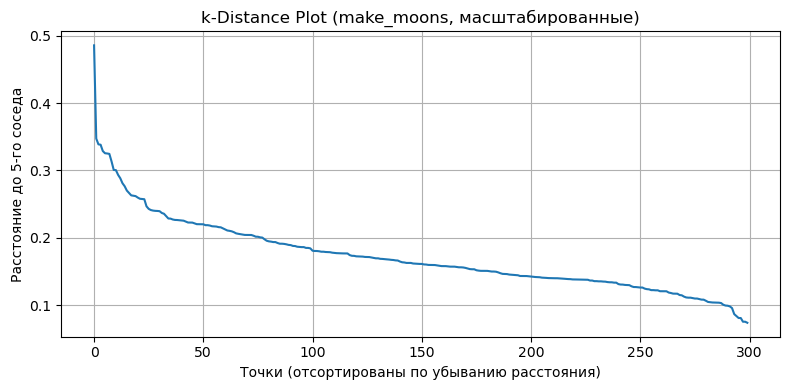

Найдите 'локоть' на графике и запишите подходящее значение eps:
0.27 - оптимальный esp


In [4]:
# Масштабируем данные
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

k = 5

# YOUR CODE HERE
# 1. Создайте NearestNeighbors(n_neighbors=k) и обучите на X_moons_scaled
# 2. Вызовите .kneighbors() для получения матрицы расстояний
# 3. Возьмите расстояние до k-го соседа (последний столбец distances)
# 4. Отсортируйте по убыванию #нахуя? вот нахуя? у нас же все равно будет видно

modelka = NearestNeighbors(n_neighbors=k).fit(X_moons_scaled)
dist, _ = modelka.kneighbors()
k_distances_moons = dist[:,-1]
k_distances_moons = np.sort(k_distances_moons)[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_moons, масштабированные)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Найдите 'локоть' на графике и запишите подходящее значение eps:")
esp_optimal = 0.27 #на глаз
print(f"{esp_optimal} - оптимальный esp")

**❓ Вопрос для размышления:** Где находится «локоть»? Как он указывает на границу между точками кластеров и шумом?


---
## Шаг 4. DBSCAN на нелинейных датасетах

Применим DBSCAN к `make_moons` и `make_circles`. Обратите внимание на масштабирование.

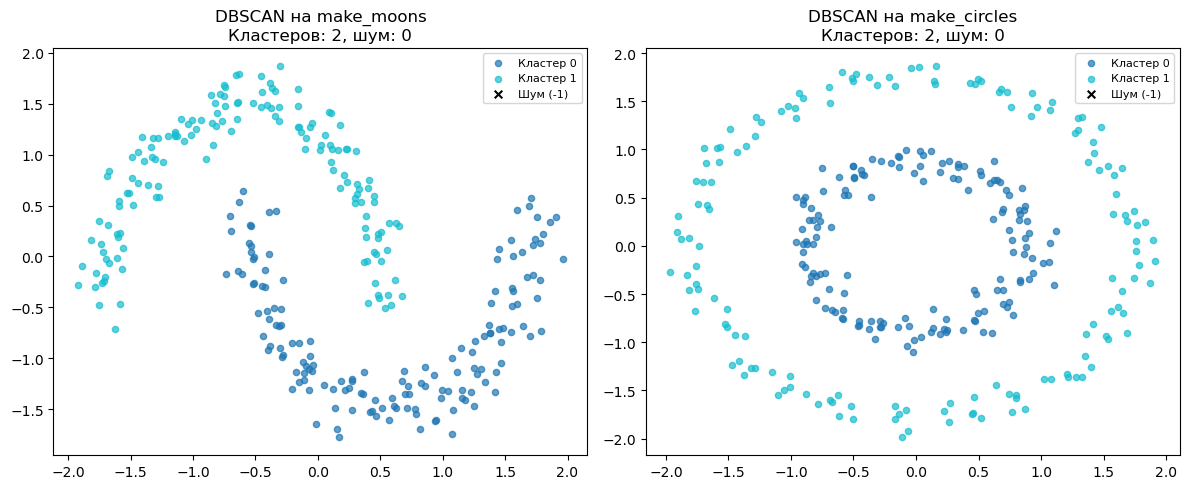

In [5]:
# Масштабируем make_circles
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

# YOUR CODE HERE
# 1. Создайте DBSCAN с подобранным eps (из k-distance plot) и min_samples=5
# 2. Примените fit_predict к X_moons_scaled и X_circles_scaled
# 3. Подберите параметры так, чтобы алгоритм нашёл 2 кластера

db_moons = DBSCAN(eps=esp_optimal)
labels_db_moons = db_moons.fit_predict(X_moons_scaled)

db_circles = DBSCAN(eps=0.35) 
# взяли примерно подходящий eps (без графика но вменяемый) 
labels_db_circles = db_circles.fit_predict(X_circles_scaled)

# Вспомогательная функция для визуализации
def plot_dbscan_results(X, labels, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые точки — крупные, граничные — обычные, шум — крестики."""
    noise_mask = labels == -1
    colors = cm.tab10(np.linspace(0, 1, max(labels)+1)) if max(labels) >= 0 else []
    
    for i in range(max(labels)+1):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7,
                   color=colors[i], label=f'Кластер {i}')
    
    ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
               s=30, c='black', marker='x', label='Шум (-1)')
    
    n_cl = max(labels) + 1 if max(labels) >= 0 else 0
    n_noise = noise_mask.sum()
    ax.set_title(f"{title}\nКластеров: {n_cl}, шум: {n_noise}")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons, "DBSCAN на make_moons", axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles, "DBSCAN на make_circles", axes[1])
plt.tight_layout()
plt.show()

---
## Шаг 5. Сравнение DBSCAN и K-Means на нелинейных данных

In [6]:
# Сравнение силуэта DBSCAN vs K-Means для make_moons

# YOUR CODE HERE
# 1. Обучите KMeans(n_clusters=2) на X_moons_scaled
# 2. Вычислите silhouette_score для K-Means
# 3. Вычислите silhouette_score для DBSCAN (только для некластерных точек!)
#    Подсказка: исключите точки с labels == -1 (таковых нет)

km_for_score = KMeans(random_state=RANDOM_STATE, n_clusters=2, init='k-means++').fit(X_moons_scaled)
preds_kme = km_for_score.predict(X_moons_scaled)
score_kmeans = silhouette_score(X_moons_scaled, preds_kme)
score_dbscan = silhouette_score(X_moons_scaled, labels_db_moons)

print("=== Коэффициент силуэта на make_moons ===")
print(f"K-Means (K=2): {score_kmeans:.3f}" if score_kmeans is not None else "K-Means: не вычислен")
print(f"DBSCAN:        {score_dbscan:.3f}" if score_dbscan is not None else "DBSCAN: не вычислен")

=== Коэффициент силуэта на make_moons ===
K-Means (K=2): 0.494
DBSCAN:        0.380


**❓ Вопрос для размышления:** Какой алгоритм получил лучший силуэт? Соответствует ли это визуальному впечатлению? Можно ли всегда доверять силуэту как абсолютной мере качества?

Оказывается DBSCAN получил меньше силует потому что силует любит компактные шарообразные кластеры и может
плохо относиться к правильным, но причудливым формам. можно это осознать если посмотреть на формулу силуета.
Визуальному впечатлению не соответствует

---
## Шаг 6. Исследование влияния гиперпараметров

Посмотрим, как меняется результат DBSCAN при разных значениях `eps` и `min_samples`.

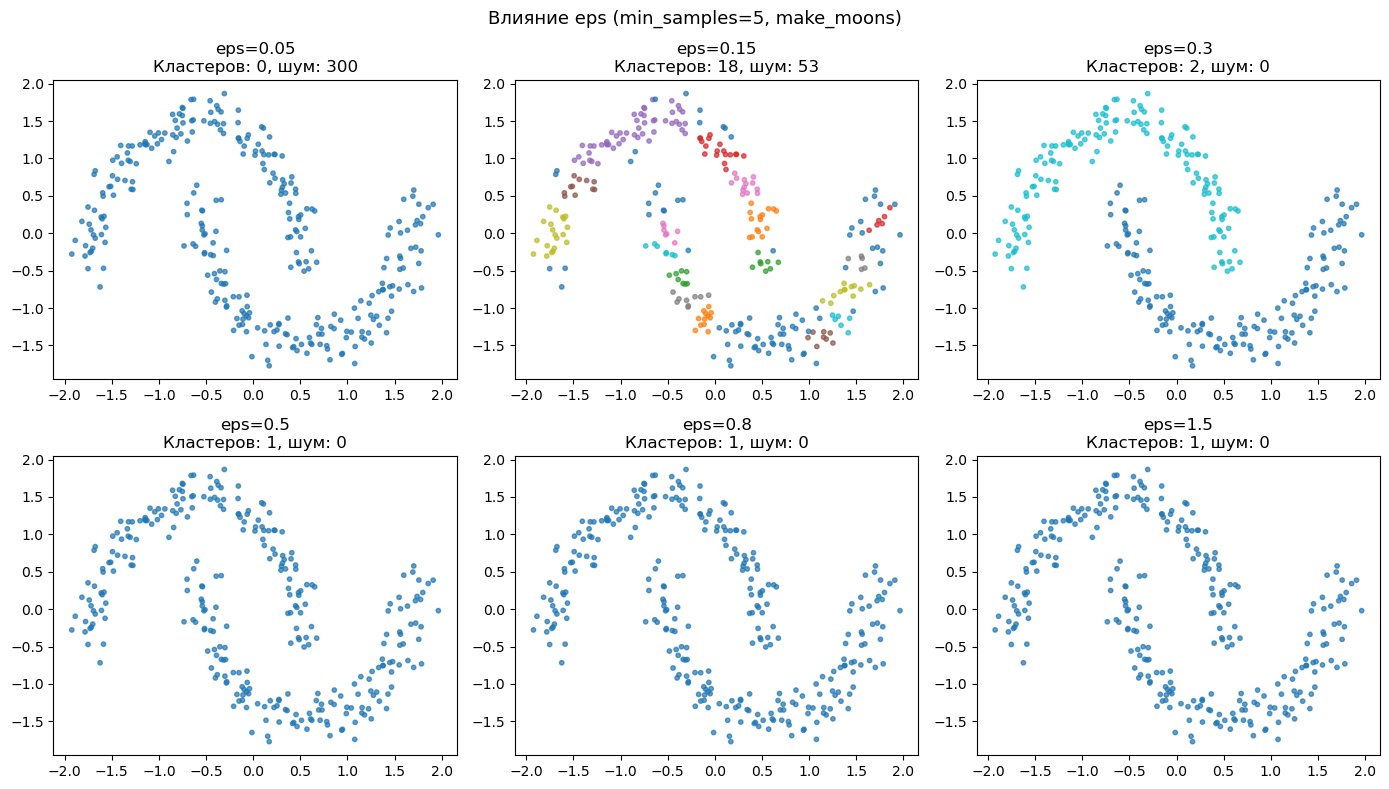

In [7]:
# Сетка eps при фиксированном min_samples=5
eps_values = [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    # YOUR CODE HERE
    # 1. Запустите DBSCAN(eps=eps_val, min_samples=5) на X_moons_scaled
    # 2. Получите метки
    # 3. Посчитайте число кластеров и шумовых точек
    # 4. Отобразите scatter plot с цветами по меткам
    #    Шумовые точки (label == -1) рисуйте чёрными крестиками
    labels_i = DBSCAN(eps=eps_val, min_samples=5).fit_predict(X_moons_scaled)
    
    
    if labels_i is not None:
        n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
        n_noise = (labels_i == -1).sum()
        axes[i].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                        c=labels_i, cmap='tab10', s=10, alpha=0.7)
        axes[i].set_title(f"eps={eps_val}\nКластеров: {n_cl}, шум: {n_noise}")
    else:
        axes[i].set_title(f"eps={eps_val} (не вычислено)")

plt.suptitle("Влияние eps (min_samples=5, make_moons)", fontsize=13)
plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** При каком `eps` алгоритм нашёл два правильных кластера? Что происходит при слишком малом и слишком большом значении?

При маленьком eps - переобучение, сильно запоминаем данные, при большом - недообучение, считем что точки сильно связаны и это просто один большой кластер. при eps = 0.3 получается нормально, это (как следует из графика) почти оптимальное значение. кстати более оптимальное значение eps можно найти, найдя максимальное значение второй "производной" функции, изображенной на k-distanse-plot. получаем аналитически оптимальное eps, что радует, ибо ошибаясь даже на две сотых (0.02) я уже видел, что кластеризация проходит не очень гладко (получили две шумные точки, пришлось бы во первых удалять, во вторых в продакшене кажется что это было бы неприятно (рекомендовали потенциальным покупателям не то что нужно, а какой то мусор - убыль для компании, если говорить про рекомендательные системы)) 


---
## Шаг 7. DBSCAN на реальном датасете Wine

Теперь перейдём к реальным данным. Датасет Wine: 178 образцов вина из трёх сортов винограда, 13 химических признаков.

In [8]:
# Загрузка датасета Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target  # истинные метки (не используем при кластеризации!)
feature_names = wine.feature_names

print(f"Форма данных: {X_wine.shape}")
print(f"Признаки: {feature_names}")
print(f"\nСтатистика признаков:")
df_wine = pd.DataFrame(X_wine, columns=feature_names)
print(df_wine.describe().round(2))

Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00             

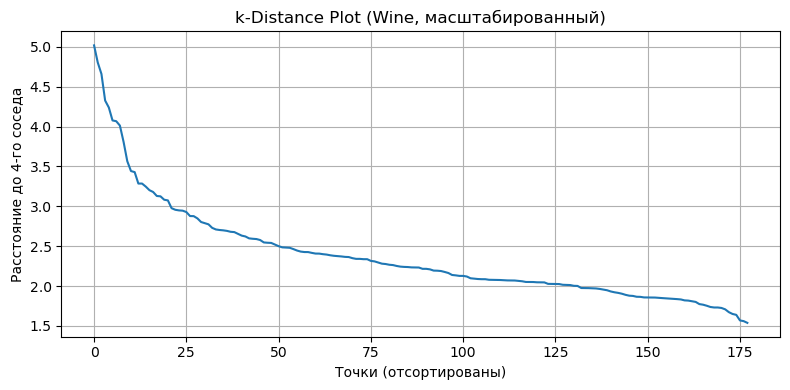

2.17 - the best param (approximately)


In [9]:
# YOUR CODE HERE
# 1. Масштабируйте X_wine с помощью StandardScaler
# 2. Постройте k-distance plot (k=4)
# 3. Визуально определите «локоть» и запишите подходящее eps
wine_scaler = StandardScaler()
X_wine_scaled = wine_scaler.fit_transform(X_wine)
k_wine = 4
nn_wine = NearestNeighbors(n_neighbors=k_wine).fit(X_wine_scaled)
listik, _ = nn_wine.kneighbors()
wine_data = listik[:, -1]
k_dist_wine = np.sort(wine_data)[::-1]


plt.figure(figsize=(8, 4))
if k_dist_wine is not None:
    plt.plot(k_dist_wine)
plt.xlabel("Точки (отсортированы)")
plt.ylabel(f"Расстояние до {k_wine}-го соседа")
plt.title("k-Distance Plot (Wine, масштабированный)")
plt.grid(True)
plt.tight_layout()
plt.show()
eps_wine = 2.17
print(f"{eps_wine} - the best param (approximately)")

In [10]:
# YOUR CODE HERE
# 1. Запустите DBSCAN на X_wine_scaled с выбранным eps и min_samples=4
# 2. Выведите: число кластеров, число шумовых точек, долю шума
# 3. Если кластеров > 1, вычислите силуэт (исключив шум)

db_wine = DBSCAN(eps=eps_wine, min_samples=4)
labels_wine = db_wine.fit_predict(X_wine_scaled)
print("=== Результаты DBSCAN на Wine ===")
print(f"{db_wine.eps} - eps")
# ваш код для вывода статистики

chislo_clusters = len(set(labels_wine)) - (1 if -1 in labels_wine else 0)
chislo_anomaliy = np.sum(labels_wine == -1)
dolua_anomaliy = chislo_anomaliy/len(labels_wine)
remove_shum = []
remove_shum_X = []
for i, el in enumerate(labels_wine):
    if el != -1:
        remove_shum.append(el)
        remove_shum_X.append(X_wine_scaled[i])
silouette = silhouette_score(remove_shum_X, remove_shum)
print(f"{chislo_clusters} - число кластеров")
print(f"{chislo_anomaliy} - число аномальных обьектов")
print(f"{dolua_anomaliy} - доля аномальных обьектов")
print(f"{silouette} - silhouette score")

=== Результаты DBSCAN на Wine ===
2.17 - eps
2 - число кластеров
52 - число аномальных обьектов
0.29213483146067415 - доля аномальных обьектов
0.3437118704437737 - silhouette score


---
## Шаг 8. Анализ шумовых точек

Шумовые точки — это объекты, которые DBSCAN не смог отнести ни к одному кластеру. В задаче кластеризации они могут нести важную информацию.

In [17]:
# YOUR CODE HERE
# 1. Выберите строки X_wine, соответствующие шумовым точкам (labels_wine == -1)
# 2. Создайте DataFrame с признаками шумовых точек
# 3. Сравните среднее значение признаков шумовых точек
#    со средним по всей выборке (df_wine.mean())
# 4. Какие признаки у шумовых точек сильно отличаются от среднего?
noise_mask_wine = []
for i, el in enumerate(labels_wine):
    if el == -1:
        noise_mask_wine.append(X_wine[i])
noise_mask_wine = np.array(noise_mask_wine)
df_noise = pd.DataFrame(noise_mask_wine, columns=df_wine.columns)
X_wine_noise = df_wine.columns    # признаки шумовых точек
print("=== Средние значения признаков ===")
mean_all = df_wine.mean()
mean_noise = df_noise.mean()

diffs = []
for col in df_wine.columns:
    diff = mean_all[col] - mean_noise[col]
    diffs.append((col, diff))
    print(f"{col:20} | all: {mean_all[col]:8.3f} | noise: {mean_noise[col]:8.3f} | diff: {diff:8.3f}")

diffs_sorted = sorted(diffs, key=lambda x: abs(x[1]), reverse=True)

print("\n=== Признаки с наибольшим отличием ===")
for i in range(3):
    col, diff = diffs_sorted[i]
    print(f"{i+1}. {col}: разница = {diff:.3f}")

=== Средние значения признаков ===
alcohol              | all:   13.001 | noise:   12.697 | diff:    0.304
malic_acid           | all:    2.336 | noise:    2.479 | diff:   -0.143
ash                  | all:    2.367 | noise:    2.351 | diff:    0.016
alcalinity_of_ash    | all:   19.495 | noise:   20.096 | diff:   -0.601
magnesium            | all:   99.742 | noise:  101.827 | diff:   -2.085
total_phenols        | all:    2.295 | noise:    2.347 | diff:   -0.052
flavanoids           | all:    2.029 | noise:    2.023 | diff:    0.006
nonflavanoid_phenols | all:    0.362 | noise:    0.366 | diff:   -0.004
proanthocyanins      | all:    1.591 | noise:    1.703 | diff:   -0.113
color_intensity      | all:    5.058 | noise:    4.399 | diff:    0.659
hue                  | all:    0.957 | noise:    0.979 | diff:   -0.022
od280/od315_of_diluted_wines | all:    2.612 | noise:    2.546 | diff:    0.066
proline              | all:  746.893 | noise:  642.365 | diff:  104.528

=== Признаки с наибо

**❓ Вопрос для размышления:** Чем отличаются шумовые точки от остальных? Являются ли они «плохими» данными или это реальные аномалии?

В данном датасете это не аномалии. Это просто так получилось что DBSCAN их посчитал аномалиями. Они далеко от корневых точек кластеров и DBSCAN не знает куда их отнести 

---
## Шаг 9. Итоговое сравнение: DBSCAN vs K-Means на Wine

0.3437118704437737 - силует на винном датасете dbscan
0.2848589191898987 - силует на винном датасете у k-means


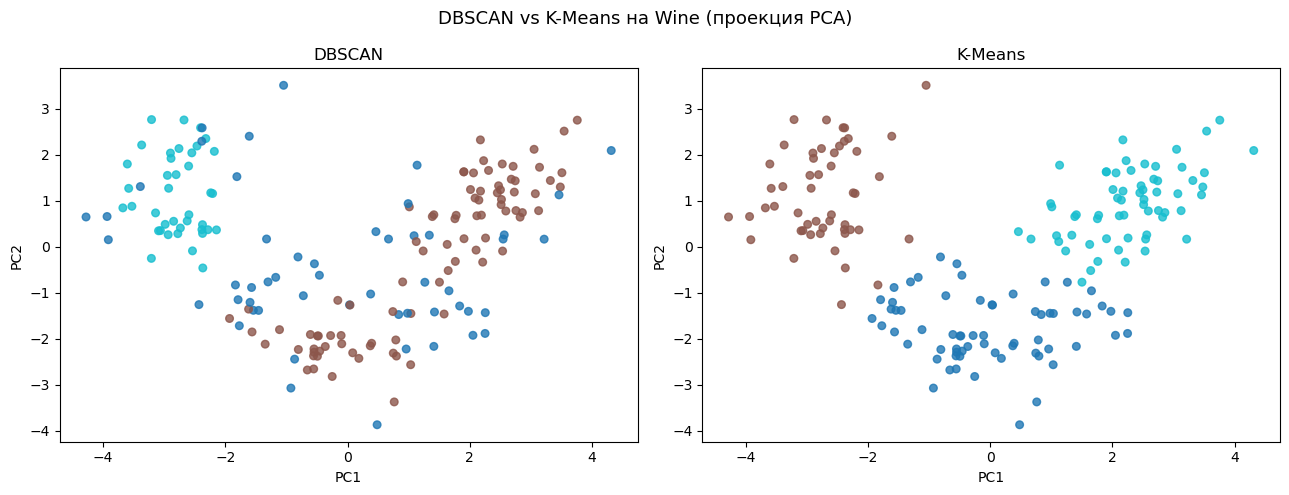

In [28]:
# YOUR CODE HERE
# 1. Обучите KMeans с числом кластеров = числу кластеров DBSCAN
#    (или с n_clusters=3, так как истинных классов 3)
# 2. Вычислите силуэт для K-Means
# 3. Сравните силуэт DBSCAN и K-Means
# 4. Визуализируйте результаты обоих методов в 2D (первые два признака
#    после масштабирования или используйте PCA до 2 компонент)

# Подсказка для PCA:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# DBSCAN
print(f"{silouette} - силует на винном датасете dbscan")

# K-Means
k_means_wine = KMeans(n_clusters=3, init='k-means++', random_state=RANDOM_STATE).fit(X_wine_scaled)
preds_wine_km = k_means_wine.predict(X_wine_scaled)
sil_kmeans = silhouette_score(X_wine_scaled, preds_wine_km)
print(f"{sil_kmeans} - силует на винном датасете у k-means")
plt.suptitle("DBSCAN vs K-Means на Wine (проекция PCA)", fontsize=13)


axes[0].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], c=labels_wine, cmap='tab10', s=30, alpha=0.8)
axes[0].set_title("DBSCAN")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], c=preds_wine_km, cmap='tab10', s=30, alpha=0.8)
axes[1].set_title("K-Means")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")


plt.tight_layout()
plt.show()

---
## Шаг 10. Итоговые выводы

Ответьте на следующие вопросы в ячейке ниже (текст Markdown):

**1. Когда DBSCAN выигрывает у K-Means?**

> Когда данные представляют собой не просто облако точек, а принимают достаточно странные формы (луны, концентрические эллипсы, окружности, и тд)

**2. Когда K-Means предпочтительнее?**

> Бейзлайн либо знаем, как устроены данные (знаем, что есть несколько достаточно хорошо распределенных облаков точек)

**3. Почему масштабирование обязательно для DBSCAN?**

> Для обоих алгоритмов необходимо, потому что оба работают с расстояниями

**4. Как интерпретировать шумовые точки в датасете Wine?**

> Либо это правда аномальное вино, либо модель запуталась в этих обьектах. такое бывает когда обьект лежит на середине между двумя кластерами

**5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?**

> Нет. как было видно силует дбскана был сильно хуже силуета k-means на датасете с лунами, но
> это произошло лишь потому что формула силуета получше сработала для круглых кластеров.